In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"reguia","key":"7d5f2b1349092e46d55898b7a3518c76"}'}

In [ ]:
! mkdir ~/.kaggle

! cp kaggle.json ~/.kaggle/

! chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d marcosgabriel/infrared-solar-modules

Dataset URL: https://www.kaggle.com/datasets/marcosgabriel/infrared-solar-modules
License(s): MIT
  0% 0.00/15.2M [00:00<?, ?B/s]
100% 15.2M/15.2M [00:00<00:00, 1.24GB/s]


In [ ]:
!unzip /content/infrared-solar-modules.zip

Streaming output truncated to the last 5000 lines.
  inflating: 2020-02-14_InfraredSolarModules/InfraredSolarModules/images/5500.jpg  
  inflating: 2020-02-14_InfraredSolarModules/InfraredSolarModules/images/5501.jpg  
  inflating: 2020-02-14_InfraredSolarModules/InfraredSolarModules/images/5502.jpg  
  inflating: 2020-02-14_InfraredSolarModules/InfraredSolarModules/images/5503.jpg  
  inflating: 2020-02-14_InfraredSolarModules/InfraredSolarModules/images/5504.jpg  
  inflating: 2020-02-14_InfraredSolarModules/InfraredSolarModules/images/5505.jpg  
  inflating: 2020-02-14_InfraredSolarModules/InfraredSolarModules/images/5506.jpg  
  inflating: 2020-02-14_InfraredSolarModules/InfraredSolarModules/images/5507.jpg  
  inflating: 2020-02-14_InfraredSolarModules/InfraredSolarModules/images/5508.jpg  
  inflating: 2020-02-14_InfraredSolarModules/InfraredSolarModules/images/5509.jpg  
  inflating: 2020-02-14_InfraredSolarModules/InfraredSolarModules/images/551.jpg  
  inflating: 2020-02-14_In

In [ ]:
import os
import pandas as pd
from sklearn.utils import resample

# Paths
data_path = '/content/2020-02-14_InfraredSolarModules/InfraredSolarModules'
meta_data = os.path.join(data_path, 'module_metadata.json')

# Load and sort metadata
df = pd.read_json(meta_data, orient='index').sort_index()
df['image_filepath'] = df['image_filepath'].apply(lambda x: os.path.join(data_path, x))

# Separate No-Anomaly class and others
no_anomaly_df = df[df['anomaly_class'] == 'No-Anomaly']
anomaly_df = df[df['anomaly_class'] != 'No-Anomaly']

# Undersample No-Anomaly class
no_anomaly_sampled = resample(no_anomaly_df, replace=False, n_samples=6000, random_state=42)

# Combine balanced dataset
df_balanced = pd.concat([anomaly_df, no_anomaly_sampled])

# Update file paths
df_balanced['image_filepath'] = df_balanced['image_filepath'].apply(lambda x: os.path.join(data_path, x))

# Shuffle and reset index
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Show the first few rows
df_balanced.head()


,image_filepath,anomaly_class
0,/content/2020-02-14_InfraredSolarModules/Infra...,Vegetation
1,/content/2020-02-14_InfraredSolarModules/Infra...,Cell-Multi
2,/content/2020-02-14_InfraredSolarModules/Infra...,Cell
3,/content/2020-02-14_InfraredSolarModules/Infra...,Offline-Module
4,/content/2020-02-14_InfraredSolarModules/Infra...,Soiling


In [ ]:
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(df_balanced, test_size=0.3, random_state=42)

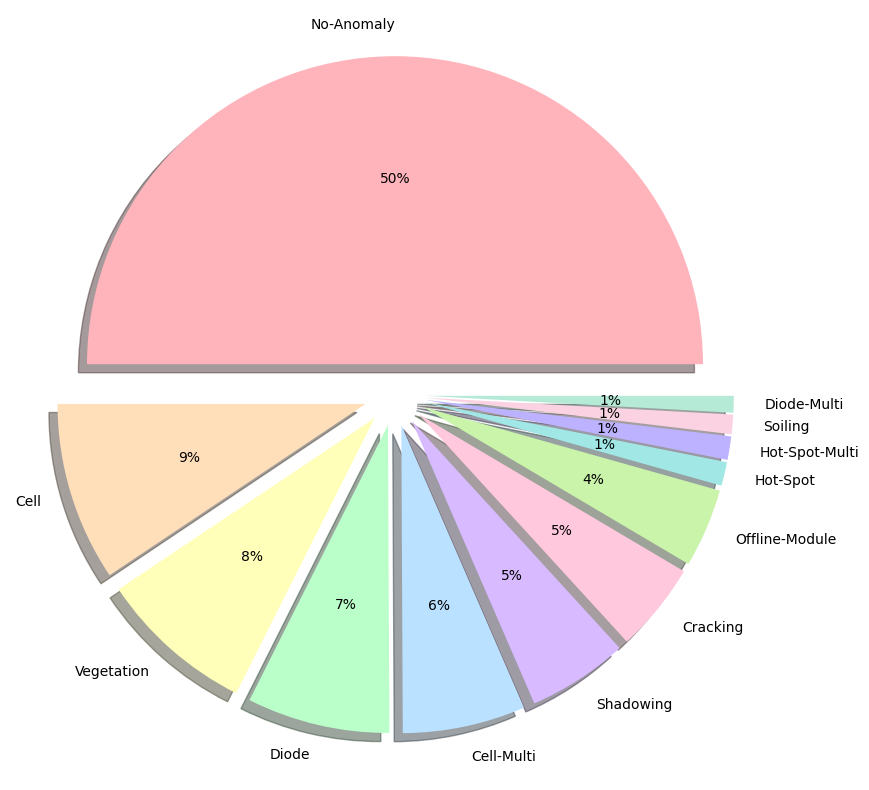

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cv2  # Not used in this snippet, but imported

# Optional: Only keep as many colors as you have classes
# Soft pastel colors
colors = [
    "#FFB3BA", "#FFDFBA", "#FFFFBA", "#BAFFC9", "#BAE1FF",
    "#D7BAFF", "#FFC8DD", "#C9F4AA", "#A0E7E5", "#BDB2FF",
    "#FAD2E1", "#B5EAD7"
]

# Plot
plt.figure(figsize=(10,10))
df['anomaly_class'].value_counts().plot(
    kind='pie',
    autopct='%1.0f%%',
    explode=[0.1]*12,
    shadow=True,
    colors=colors
)
plt.ylabel("")  # Removes 'anomaly_class' label from side
plt.show()

In [ ]:
import numpy as np
import cv2
import pandas as pd
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder
import albumentations as A
from imblearn.over_sampling import RandomOverSampler
# Load data
data1 = []
labels1 = []

# Apply Histogram Equalization and Load Data
for img_path in train_df['image_filepath']:
    img = cv2.imread(img_path,0)  # Read as grayscale
    if img is None:
        continue
    img = cv2.equalizeHist(img)  # Histogram equalization
    data1.append(img)
    label = train_df.loc[train_df['image_filepath'] == img_path, 'anomaly_class'].values[0]
    labels1.append(label)

# Convert to numpy arrays and normalize
data1 = np.array(data1) / 255.0
labels1 = np.array(labels1)

# Ensure data1 has shape (num_samples, height, width, 1)
data1 = np.expand_dims(data1, axis=-1)  # Add channel dimension

# Define augmentation pipeline
augmentation_pipeline = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=15, p=0.5),
    A.ElasticTransform(alpha=1, sigma=50, p=0.3),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=0, p=0.5),
    A.GridDistortion(num_steps=5, distort_limit=0.05, p=0.3),
    A.OpticalDistortion(distort_limit=0.05, shift_limit=0.05, p=0.3),  # Lens-like warping
    A.PiecewiseAffine(scale=(0.01, 0.05), p=0.3),  # Local distortions
    A.Affine(translate_percent=(-0.1, 0.1), shear=(-10, 10), p=0.5)  # Shearing & translation
])


# Data Augmentation for Underrepresented Classes
TARGET_COUNT = 2000
augmentation_classes = train_df['anomaly_class'].value_counts()
ag = []
ag_labels = []

for anomaly, count in augmentation_classes.items():
    class_images = train_df[train_df['anomaly_class'] == anomaly]['image_filepath']
    current_count = count

    while current_count < TARGET_COUNT:
        for img_path in class_images:
            if current_count >= TARGET_COUNT:
                break
            img = cv2.imread(img_path, 0)  # Read as grayscale
            if img is None:
                continue
            img = cv2.equalizeHist(img)  # Apply histogram equalization

            # Convert to Albumentations format (add channel)
            img = np.expand_dims(img, axis=-1)

            # Apply Random Augmentation
            augmented = augmentation_pipeline(image=img)["image"]

            # Ensure augmented images have shape (height, width, 1)
            augmented = np.expand_dims(augmented, axis=-1) if augmented.ndim == 2 else augmented

            if isinstance(augmented, np.ndarray):
                ag.append(augmented)
                ag_labels.append(anomaly)
                current_count += 1

# Convert augmented images to numpy array and normalize
ag = np.array(ag) / 255.0
ag_labels = np.array(ag_labels)

# Ensure ag has shape (num_samples, height, width, 1)
ag = np.expand_dims(ag, axis=-1) if ag.ndim == 3 else ag

# Ensure both data1 and ag have the same shape before concatenation
print("data1 shape:", data1.shape)
print("ag shape:", ag.shape)

# Combine Original and Augmented Data
data1 = np.concatenate((data1, ag), axis=0)
labels1 = np.concatenate((labels1, ag_labels), axis=0)

# n_samples, img_height, img_width, channels = data1.shape
# data1_flat = data1.reshape(n_samples, -1)


# # Reshape for SMOTE
# n_samples, img_height, img_width, _ = data1.shape
# data1 = data1.reshape(n_samples, img_height * img_width)

# # Apply SMOTE to Balance Dataset
# smote = SMOTE(sampling_strategy='auto', random_state=42)
# data1, labels1 = smote.fit_resample(data1, labels1)

# # Reshape Back to Image Format
# data1 = data1.reshape(-1, img_height, img_width,1)

print("Final dataset shape:", data1.shape, labels1.shape)

/usr/local/lib/python3.11/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
<ipython-input-8-2633118032>:37: UserWarning: Argument(s) 'shift_limit' are not valid for transform OpticalDistortion
  A.OpticalDistortion(distort_limit=0.05, shift_limit=0.05, p=0.3),  # Lens-like warping
/usr/local/lib/python3.11/dist-packages/albumentations/core/validation.py:114: UserWarning: This augmenter is very slow. Try to use ``ElasticTransform`` instead, which is at least 10x faster.
  original_init(self, **validated_kwargs)


data1 shape: (11200, 40, 24, 1)
ag shape: (15008, 40, 24, 1)
Final dataset shape: (26208, 40, 24, 1) (26208,)


In [ ]:
# from imblearn.over_sampling import RandomOverSampler
from collections import Counter
#Count the occurrences of each class in the original dataset
y = labels1
print("Class distribution before oversampling:", Counter(y))

# Create a RandomOverSampler
ros = RandomOverSampler(random_state=42)

X = data1

if len(X.shape) == 4:
    # If images are RGB, reshape to (num_samples, height * width * channels)
    X = X.reshape(X.shape[0], -1)


# Create a RandomOverSampler
ros = RandomOverSampler(random_state=42)

# Fit and apply the oversampler
X_resampled, y_resampled = ros.fit_resample(X, y)

# If you reshaped the input, reshape it back to its original shape
if len(X.shape) == 2:
    X_resampled = X_resampled.reshape(X_resampled.shape[0], 40, 24, 1)

#Count the occurrences of each class after oversampling
print("Class distribution after oversampling:", Counter(y_resampled))

Class distribution before oversampling: Counter({np.str_('No-Anomaly'): 4208, np.str_('Cell-Multi'): 2000, np.str_('Shadowing'): 2000, np.str_('Hot-Spot-Multi'): 2000, np.str_('Cell'): 2000, np.str_('Vegetation'): 2000, np.str_('Cracking'): 2000, np.str_('Diode'): 2000, np.str_('Offline-Module'): 2000, np.str_('Diode-Multi'): 2000, np.str_('Soiling'): 2000, np.str_('Hot-Spot'): 2000})
Class distribution after oversampling: Counter({np.str_('Cell-Multi'): 4208, np.str_('No-Anomaly'): 4208, np.str_('Shadowing'): 4208, np.str_('Hot-Spot-Multi'): 4208, np.str_('Cell'): 4208, np.str_('Vegetation'): 4208, np.str_('Cracking'): 4208, np.str_('Diode'): 4208, np.str_('Offline-Module'): 4208, np.str_('Diode-Multi'): 4208, np.str_('Soiling'): 4208, np.str_('Hot-Spot'): 4208})


In [ ]:
train_data = X_resampled
train_labels = y_resampled
train_data.shape, train_labels.shape

((50496, 40, 24, 1), (50496,))

In [ ]:
import cv2
import numpy as np
import pandas as pd

x_test = []
y_test = []

# Process test set exactly the same way as training set
for img_path in test_df['image_filepath']:
    # Read image in grayscale
    img = cv2.imread(img_path, 0)

    # Apply histogram equalization
    img = cv2.equalizeHist(img)

    label = test_df.loc[test_df['image_filepath'] == img_path, 'anomaly_class'].values[0]
    # Append image and label to lists
    x_test.append(img)
    y_test.append(label)

# Convert lists to numpy arrays and normalize
x_test = np.array(x_test) / 255.0
y_test = np.array(y_test)

# Ensure x_test has shape (num_samples, height, width, 3)
print(x_test.shape, y_test.shape)  # Expected: (num_samples, H, W, 3), (num_samples,)

(4800, 40, 24) (4800,)


In [ ]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
import numpy as np

# Fit the encoder on the combined labels
encoder = LabelEncoder()

# Transform and one-hot encode
y_train = encoder.fit_transform(train_labels)
y_train = to_categorical(y_train)

y_test = encoder.fit_transform(y_test)
y_test = to_categorical(y_test)

print(f"Encoded y_train shape: {y_train.shape}")
print(f"Encoded y_test shape: {y_test.shape}")
print(f"Classes: {encoder.classes_}")

Encoded y_train shape: (50496, 12)
Encoded y_test shape: (4800, 12)
Classes: ['Cell' 'Cell-Multi' 'Cracking' 'Diode' 'Diode-Multi' 'Hot-Spot'
 'Hot-Spot-Multi' 'No-Anomaly' 'Offline-Module' 'Shadowing' 'Soiling'
 'Vegetation']


In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, BatchNormalization
model = Sequential()
model.add(Conv2D(32, (3,3), padding = "same", activation = "relu", input_shape = (40,24,1)))
#model.add(BatchNormalization())
#model.add(MaxPool2D())

model.add(Conv2D(64, (3,3), padding = "same", activation = "relu"))
model.add(BatchNormalization())
model.add(MaxPool2D())

model.add(Conv2D(256, (3,3), padding = "same", activation = "relu"))
model.add(BatchNormalization())
model.add(MaxPool2D())

model.add(Conv2D(256, (3,3), padding = "same", activation = "relu"))
model.add(BatchNormalization())
model.add(MaxPool2D())

model.add(Conv2D(512, (3,3), padding = "same", activation = "relu"))
model.add(BatchNormalization())
model.add(MaxPool2D())

model.add(Flatten())
model.add(Dense(256, activation ="relu"))
model.add(Dropout(0.5))
model.add(Dense(256, activation ="relu"))
model.add(Dropout(0.5))
model.add(Dense(12, activation ="softmax"))

print(model.summary())

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 40, 24, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 40, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 40, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 20, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 20, 12, 256)    │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 20, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 6, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 10, 6, 256)     │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10, 6, 256)     │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 5, 3, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 5, 3, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 12)             │         3,084 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,272,396 (8.67 MB)

 Trainable params: 2,270,220 (8.66 MB)

 Non-trainable params: 2,176 (8.50 KB)

None


In [ ]:

from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import clone_model
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam
from keras.metrics import AUC
from keras.losses import CategoricalCrossentropy
import tensorflow as tf
import numpy as np

# Compute class weights
class_weights = compute_class_weight('balanced', classes=np.unique(labels1), y=labels1)
class_weights = dict(enumerate(class_weights))

# Custom F1-Score metric
precision_metric = tf.keras.metrics.Precision()
recall_metric = tf.keras.metrics.Recall()

def f1_score(y_true, y_pred):
    precision = precision_metric(y_true, y_pred)
    recall = recall_metric(y_true, y_pred)
    return 2 * (precision * recall) / (precision + recall + tf.keras.backend.epsilon())

# Custom G-Mean metric
recall_metric_gmean = tf.keras.metrics.Recall()

def g_mean(y_true, y_pred):
    recall = recall_metric_gmean(y_true, y_pred)
    tn = tf.cast(tf.math.count_nonzero((1 - y_true) * (1 - tf.round(y_pred))), dtype=tf.float32)
    fp = tf.cast(tf.math.count_nonzero((1 - y_true) * tf.round(y_pred)), dtype=tf.float32)
    tnr = tn / (tn + fp + tf.keras.backend.epsilon())
    return tf.sqrt(recall * tnr)

# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Optimizer
opt = Adam(learning_rate=5e-4)

# Compile the model
model.compile(optimizer=opt,
              metrics=["accuracy", AUC(curve='PR', name='AUC-PR'), f1_score, g_mean],
              loss=CategoricalCrossentropy())

# Train the model with class weights
history_train = model.fit(train_data, y_train,
                          batch_size=64,
                          validation_split=0.2,
                          epochs=100,
                          class_weight=class_weights, callbacks=[early_stopping])
#

Epoch 1/100
632/632 ━━━━━━━━━━━━━━━━━━━━ 35s 35ms/step - AUC-PR: 0.2460 - accuracy: 0.2382 - f1_score: 0.1013 - g_mean: 0.2297 - loss: 2.3765 - val_AUC-PR: 0.1291 - val_accuracy: 0.0908 - val_f1_score: 0.2138 - val_g_mean: 0.3541 - val_loss: 2.4860
Epoch 2/100
632/632 ━━━━━━━━━━━━━━━━━━━━ 21s 16ms/step - AUC-PR: 0.4654 - accuracy: 0.4148 - f1_score: 0.2238 - g_mean: 0.3628 - loss: 1.7902 - val_AUC-PR: 0.2133 - val_accuracy: 0.1483 - val_f1_score: 0.2785 - val_g_mean: 0.4131 - val_loss: 2.1951
Epoch 3/100
632/632 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - AUC-PR: 0.5608 - accuracy: 0.4901 - f1_score: 0.2861 - g_mean: 0.4194 - loss: 1.5479 - val_AUC-PR: 0.2652 - val_accuracy: 0.2266 - val_f1_score: 0.3242 - val_g_mean: 0.4528 - val_loss: 2.0053
Epoch 4/100
632/632 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - AUC-PR: 0.6304 - accuracy: 0.5557 - f1_score: 0.3311 - g_mean: 0.4585 - loss: 1.3712 - val_AUC-PR: 0.3473 - val_accuracy: 0.2718 - val_f1_score: 0.3654 - val_g_mean: 0.4880 - val_loss: 1.8092
Epoc

In [ ]:
x_test.shape, y_test.shape

((4800, 40, 24), (4800, 12))

In [ ]:
# Evaluate the model on the test set
x_test = x_test.reshape(-1, 40, 24, 1)
evaluation = model.evaluate(x_test, y_test, batch_size=256)
print(f"Test Loss: {evaluation[0]:.4f}")
print(f"Test Accuracy: {evaluation[1]:.4f}")
print(f"Test AUC-PR: {evaluation[2]:.4f}")
print(f"Test F1-Score: {evaluation[3]:.4f}")
print(f"Test G-Mean: {evaluation[4]:.4f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 126ms/step - AUC-PR: 0.6718 - accuracy: 0.6647 - f1_score: 0.9056 - g_mean: 0.9152 - loss: 2.3623
Test Loss: 2.3503
Test Accuracy: 0.6633
Test AUC-PR: 0.6663
Test F1-Score: 0.9056
Test G-Mean: 0.9150


150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


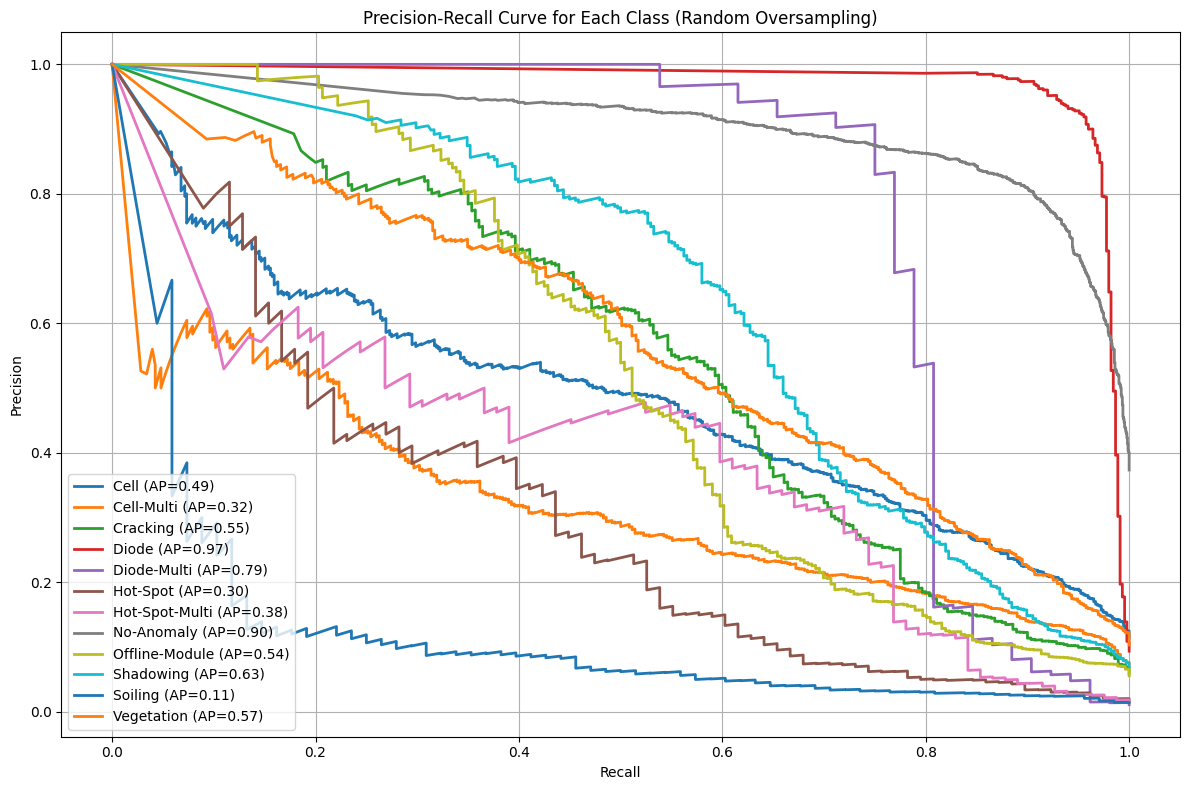

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np

# Predict probabilities (not classes!)
y_pred_proba = model.predict(x_test)

# Number of classes
n_classes = y_test.shape[1]

# Get class names from the label encoder
class_names = encoder.classes_

# Plot PR Curve for each class
plt.figure(figsize=(12, 8))
for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_test[:, i], y_pred_proba[:, i])
    ap_score = average_precision_score(y_test[:, i], y_pred_proba[:, i])
    plt.plot(recall, precision, lw=2, label=f"{class_names[i]} (AP={ap_score:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Each Class (Random Oversampling)")
plt.legend(loc="lower left")
plt.grid(True)
plt.tight_layout()
plt.show()

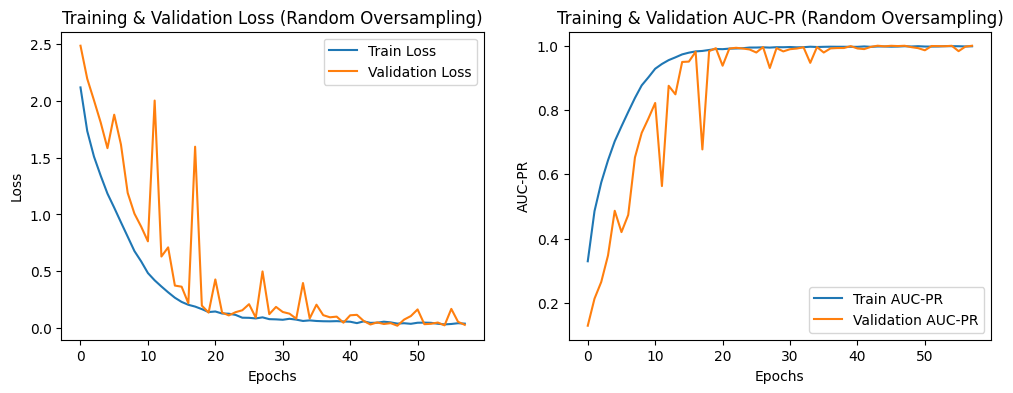

In [ ]:
loss = history_train.history['loss']
auc = history_train.history['AUC-PR']
acc = history_train.history['accuracy']
f1 = history_train.history['f1_score']
gmean = history_train.history['g_mean']


val_loss = history_train.history['val_loss']
val_auc = history_train.history['val_AUC-PR']
val_acc = history_train.history['val_accuracy']
val_f1 = history_train.history['val_f1_score']
val_gmean = history_train.history['val_g_mean']



#plot Accuracy Curve
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training & Validation Loss (Random Oversampling)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(auc, label='Train AUC-PR')
plt.plot(val_auc, label='Validation AUC-PR')
plt.xlabel('Epochs')
plt.ylabel('AUC-PR')
plt.title('Training & Validation AUC-PR (Random Oversampling)')
plt.legend()

# #plot Loss Curve
# plt.subplot(3, 2, 3)
# plt.plot(acc, label='Train Accuracy')
# plt.plot(val_acc, label='Validation Accuracy')
# plt.xlabel('Epochs')
# plt.ylabel('Loss')
# plt.title('Training & Validation Accuracy')
# plt.legend()

# #plot Loss Curve
# plt.subplot(3, 2, 4)
# plt.plot(f1, label='Train F1-Score')
# plt.plot(val_f1, label='Validation F1-Score')
# plt.xlabel('Epochs')
# plt.ylabel('Loss')
# plt.title('Training & Validation F1-Score')
# plt.legend()

# #plot Loss Curve
# plt.subplot(3, 2, 5)
# plt.plot(gmean, label='Train G-Mean')
# plt.plot(val_gmean, label='Validation G-Mean')
# plt.xlabel('Epochs')
# plt.ylabel('Loss')
# plt.title('Training & Validation G-Mean')
# plt.legend()

plt.show()

150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


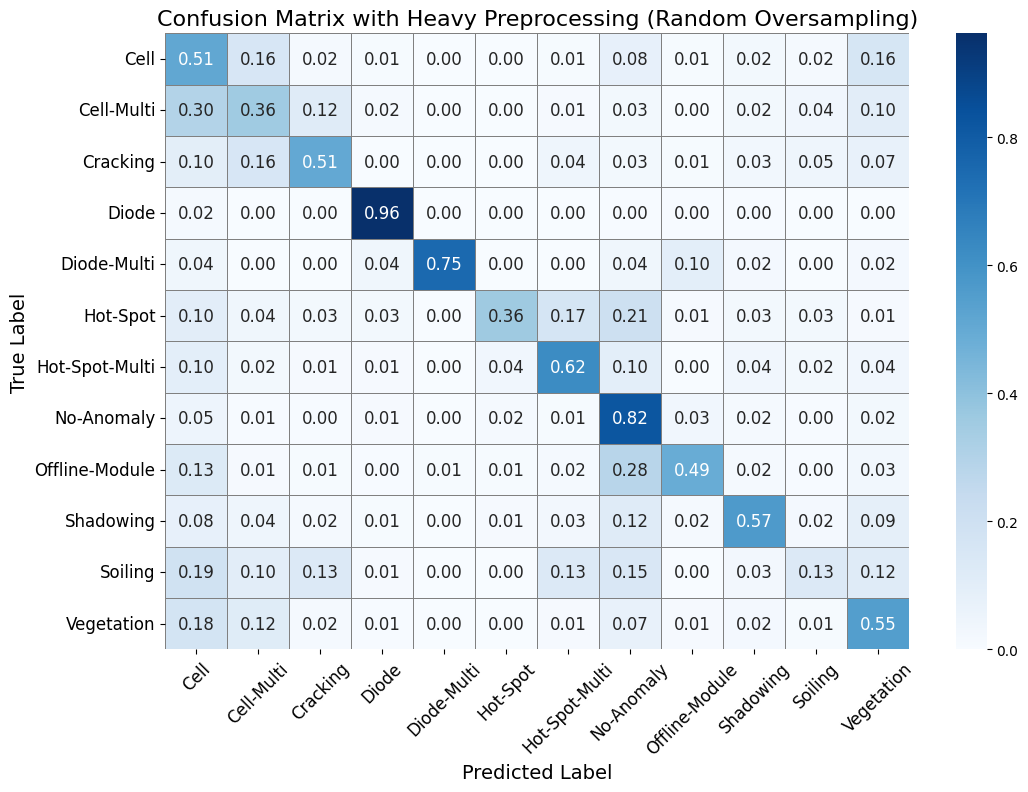

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Get model predictions (probabilities)
y_pred = model.predict(x_test)

# Define thresholds per class (same length as number of classes)
# Example: You can tune these thresholds via validation set performance.
# Here, all are 0.5 initially — adjust according to class imbalance.
thresholds = np.array([0.5] * y_pred.shape[1])

# Apply thresholds — classify as class with highest probability if it exceeds threshold,
# else assign to a fallback class (like majority or unknown class)
y_pred_classes = []
for probs in y_pred:
    above_thresh = np.where(probs >= thresholds)[0]
    if len(above_thresh) > 0:
        # Choose highest prob class among those above threshold
        chosen_class = above_thresh[np.argmax(probs[above_thresh])]
    else:
        # If no class exceeds threshold, assign to a default class (e.g. 'No-Anomaly' if index=0)
        chosen_class = 0
    y_pred_classes.append(chosen_class)
y_pred_classes = np.array(y_pred_classes)

# True classes
y_true_classes = np.argmax(y_test, axis=1)

# Compute and normalize confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Define class labels
class_labels = encoder.classes_

# Plot using seaborn
plt.figure(figsize=(12, 8))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues", linewidths=0.5, linecolor='gray',
            xticklabels=class_labels, yticklabels=class_labels, cbar=True, annot_kws={"size": 12})

# Aesthetics
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)
plt.title("Confusion Matrix with Heavy Preprocessing (Random Oversampling)", fontsize=16)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.show()